In [1]:
import EL
from typing import Dict, Any, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set()

/Users/jiguangli/opt/anaconda3/envs/EL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Simulation overidentified linear IV with endogeneity.

- DGP: Consider an over-identification scenario: let $z_1$, $z_2$ be instrumental variables, $u$ (structural) and $v$ (first-stage) be errors such that $(z_1, z_2) \bot (u,v)$. If $cov(u,v) \neq 0$, then $cov(x,u) \neq 0$, then OLS is biased. 
\begin{align}
x &= \pi_1 z_1 + \pi_2 z_2 + v \\
y &= \beta x +u 
\end{align}
- We would like to target $\beta$ so the moment conditions are
$$E[z_1(y-\beta x)]=0, \quad E[z_2(y-\beta x)]=0$$

- Parameter choice: $\beta=1$, $\pi_1=0.8, \pi_2=0.6, \rho_{uv} = 0.4$.

In [2]:
# Simulation DGP

def simulate_iv_overidentified(
    n: int,
    beta: float = 1.0,
    pi1: float = 0.8,
    pi2: float = 0.6,
    rho_uv: float = 0.4,
    seed: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    DGP:
      x = pi1*z1 + pi2*z2 + v
      y = beta*x + u
    (z1,z2) ~ N(0,1) i.i.d., (u,v) jointly normal with corr rho_uv.
    Returns:
      X: (N,4) with columns [y, x, z1, z2]
      theta0: (1,) initial beta (OLS as a cheap start)
      theta_true: (1,) true beta used in simulation
    """
    rng = np.random.default_rng(seed)

    # Instruments
    z1 = rng.normal(size=n)
    z2 = rng.normal(size=n)

    # Correlated (u, v): build via correlation
    e1 = rng.normal(size=n)
    e2 = rng.normal(size=n)
    u = e1
    v = rho_uv * e1 + np.sqrt(max(0.0, 1.0 - rho_uv**2)) * e2

    # Endogenous regressor and outcome
    x = pi1 * z1 + pi2 * z2 + v
    y = beta * x + u

    X = np.column_stack([y, x, z1, z2]).astype(float)

    # Simple initial guess for beta: OLS slope (biased under endogeneity, but good numerically)
    denom = float(np.dot(x, x))
    beta_ols = float(np.dot(x, y) / denom) if denom > 1e-12 else 0.0
    theta_OLS = np.array([beta_ols], dtype=float)

    theta_true = np.array([beta], dtype=float)
    return X, theta_OLS, theta_true


def g_iv_two_instruments(X: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    IV moment function for two instruments:
      g_i(beta) = [ z1_i * (y_i - beta * x_i),  z2_i * (y_i - beta * x_i) ]
    Returns (N, 2).
    """
    y, x, z1, z2 = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    resid = y - theta[0] * x
    return np.column_stack([z1 * resid, z2 * resid])



In [3]:
def summarize_draws(
    draws: np.ndarray,
    lower_q: float = 0.05,
    upper_q: float = 0.95,
) -> dict:
    draws = np.asarray(draws, dtype=float).reshape(-1)
    draws = draws[np.isfinite(draws)]

    return {
        "Mean": np.mean(draws),
        "SD": np.std(draws, ddof=1),
        "Median": np.median(draws),
        "Lower": np.quantile(draws, lower_q),
        "Upper": np.quantile(draws, upper_q),
    }
# ---------------------------------------------------------------------
# Run one simulated dataset
# ---------------------------------------------------------------------

n = 500
beta_true = 1.0
pi1 = 0.8
pi2 = 0.6
rho_uv = 0.4
B = 10000

X_iv, beta_ols, beta_ols_plim = simulate_iv_overidentified(
    n=n,
    beta=beta_true,
    pi1=pi1,
    pi2=pi2,
    rho_uv=rho_uv,
    seed=0,
)
print(beta_ols, beta_ols_plim)

EL_iv = EL.GenELV2(
    X=X_iv,
    g=g_iv_two_instruments,
    theta0=np.array([beta_ols[0]]),
    alpha=0.0,
    m=0,
    B_nums=B,
    random_state=42,
    bounds=None,
    newton_tol=1e-8,
    newton_maxiter=100,
    newton_ridge=1e-10,
    per_v_gmm_start=True,
)

result_iv = EL_iv.fit()

posterior_draws = np.asarray(result_iv.thetas).reshape(-1)
summary = summarize_draws(posterior_draws, lower_q=0.05, upper_q=0.95)

print("True beta:", beta_true)
print("Sample OLS:", beta_ols)
print("Population OLS plim:", beta_ols_plim)
print(summary)



[1.19972254] [1.]


Bootstrap: 100%|██████████| 10000/10000 [07:34<00:00, 21.98draw/s]

True beta: 1.0
Sample OLS: [1.19972254]
Population OLS plim: [1.]
{'Mean': 0.9998407892727528, 'SD': 0.042994580808152494, 'Median': 1.0003104447944322, 'Lower': 0.9277087907255493, 'Upper': 1.0689418285453693}


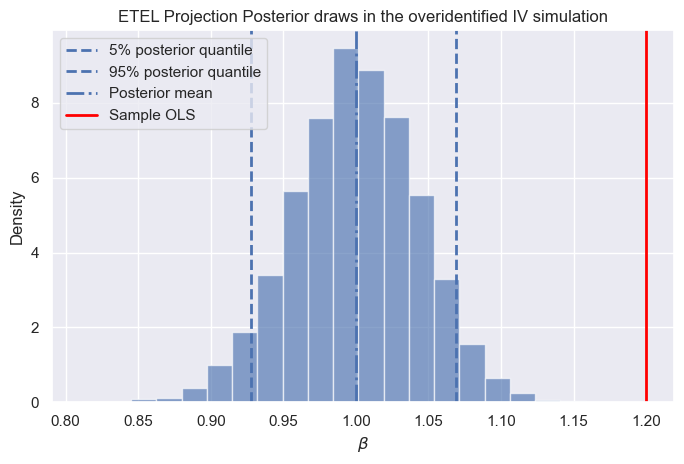

In [10]:

# ---------------------------------------------------------------------
# Plot posterior draws
# ---------------------------------------------------------------------
lower = summary["Lower"]
upper = summary["Upper"]
post_mean = summary["Mean"]

plt.figure(figsize=(7, 4.8))

plt.hist(
    posterior_draws,
    bins=20,
    density=True,
    alpha=0.65,
    edgecolor="white",
)

plt.axvline(lower, linestyle="--", linewidth=2, label="5% posterior quantile")
plt.axvline(upper, linestyle="--", linewidth=2, label="95% posterior quantile")
plt.axvline(post_mean, linestyle="-.", linewidth=2, label="Posterior mean")
#plt.axvline(beta_true, linewidth=2, label="True value")
plt.axvline(beta_ols, linewidth=2, color = "red", label="Sample OLS")

plt.xlabel(r"$\beta$")
plt.ylabel("Density")
plt.title("ETEL Projection Posterior draws in the overidentified IV simulation")
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("etel_posterior_iv_new.pdf", bbox_inches="tight")
plt.show()